# TC-Former Improved — Inference & Visualization

Завантажує навчений чекпоінт, рахує метрики, будує карту класифікації та confusion matrix.

In [1]:
# ── Налаштування ──────────────────────────────────────────────────────────────
DATASET   = 'IP'       # 'IP' | 'PU' | 'WHHH'
CKPT_PATH = '/Users/macarchic/Documents/unik/cursova_hsi/improved_paper_IP_v3_newbest_updated/seeds/seed_42/checkpoints/best-epoch=059-val_OA=0.8733.ckpt'
DATA_PATH = 'data'
SEED      = 42

## Імпорти

In [2]:
import os, warnings
from pathlib import Path
from dataclasses import dataclass
warnings.filterwarnings('ignore')

import numpy as np
import scipy.io
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from torch.utils.data import Dataset, DataLoader

sns.set_theme(style='whitegrid')
print('PyTorch:', torch.__version__)

PyTorch: 2.5.1


## Config + імена класів

In [3]:
@dataclass
class Config:
    dataset: str
    patch_size: int
    pca_components: int
    kernel_size: int
    num_classes: int
    batch_size: int
    data_path: str = 'data'
    hidden_dim: int = 64
    num_heads: int = 1
    dropout: float = 0.1
    depth: int = 2
    lr: float = 5e-4
    epochs: int = 100
    weight_decay: float = 1e-4
    patience: int = 20
    num_train_per_class: int = 10
    num_val_per_class: int = 5
    seed: int = 42
    use_fps: bool = True
    remove_pca_outliers: bool = True
    outlier_std: float = 2.5
    use_augmentation: bool = True
    use_bidirectional_wkv: bool = True
    use_pos_encoding: bool = True
    use_se_block: bool = True


CONFIGS = {
    'IP':   Config(dataset='IP',   patch_size=15, pca_components=150, kernel_size=9,  num_classes=16, batch_size=200),
    'PU':   Config(dataset='PU',   patch_size=25, pca_components=20,  kernel_size=17, num_classes=9,  batch_size=100),
    'WHHH': Config(dataset='WHHH', patch_size=31, pca_components=135, kernel_size=19, num_classes=22, batch_size=20),
}

CLASS_NAMES = {
    'IP': {
        1:'Alfalfa', 2:'Corn-notill', 3:'Corn-mintill', 4:'Corn',
        5:'Grass-pasture', 6:'Grass-trees', 7:'Grass-pasture-mowed',
        8:'Hay-windrowed', 9:'Oats', 10:'Soybean-notill',
        11:'Soybean-mintill', 12:'Soybean-clean', 13:'Wheat',
        14:'Woods', 15:'Buildings-Grass-Trees', 16:'Stone-Steel-Towers',
    },
    'PU': {
        1:'Asphalt', 2:'Meadows', 3:'Gravel', 4:'Trees',
        5:'Painted metal sheets', 6:'Bare Soil', 7:'Bitumen',
        8:'Self-Blocking Bricks', 9:'Shadows',
    },
    'WHHH': {
        1:'Red roof', 2:'Road', 3:'Bare soil', 4:'Cotton',
        5:'Cotton firewood', 6:'Paddy', 7:'Water', 8:'Rape',
        9:'Chinese cabbage', 10:'Pakchoi', 11:'Cabbage', 12:'Tuber mustard',
        13:'Brassica parachinensis', 14:'Brassica chinensis',
        15:'Small Brassica chinensis', 16:'Lactuca sativa',
        17:'Celtuce', 18:'Film-covered lettuce', 19:'Romaine lettuce',
        20:'Stem lettuce', 21:'Garlic sprout', 22:'Broad bean',
    },
}

cfg = CONFIGS[DATASET]
cfg.data_path = DATA_PATH
cfg.seed      = SEED
names = CLASS_NAMES[DATASET]
print(f'Dataset: {DATASET}  |  {cfg.num_classes} classes  |  patch {cfg.patch_size}px  |  PCA {cfg.pca_components}')

Dataset: IP  |  16 classes  |  patch 15px  |  PCA 150


## Модель (визначення)

In [4]:
class WKVOperator(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.w_log = nn.Parameter(torch.zeros(dim))
        self.u     = nn.Parameter(torch.zeros(dim))
    def forward(self, k, v):
        B, T, C = k.shape
        w       = -torch.exp(self.w_log)
        idx     = torch.arange(T, device=k.device, dtype=k.dtype)
        exp     = (idx.unsqueeze(1) - idx.unsqueeze(0) - 1).unsqueeze(-1) * w
        causal  = idx.unsqueeze(1) > idx.unsqueeze(0)
        exp_s   = exp.masked_fill(~causal.unsqueeze(-1).expand_as(exp), float('-inf'))
        decay   = torch.exp(exp_s)
        ek      = torch.exp(k)
        dp      = decay.permute(2, 0, 1)
        A       = torch.bmm(dp, (ek*v).permute(2,1,0)).permute(2,1,0)
        B_den   = torch.bmm(dp, ek.permute(2,1,0)).permute(2,1,0)
        euk     = torch.exp(self.u + k)
        return (A + euk*v) / (B_den + euk + 1e-8)

class BidirectionalWKVOperator(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.wkv_fwd = WKVOperator(dim)
        self.wkv_bwd = WKVOperator(dim)
        self.merge   = nn.Linear(2*dim, dim, bias=False)
        with torch.no_grad(): self.merge.weight.copy_(0.5*torch.eye(dim).repeat(1,2))
    def forward(self, k, v):
        fwd = self.wkv_fwd(k, v)
        bwd = self.wkv_bwd(k.flip(1), v.flip(1)).flip(1)
        return self.merge(torch.cat([fwd, bwd], dim=-1))

class TimeMixing(nn.Module):
    def __init__(self, dim, wkv_cls=WKVOperator):
        super().__init__()
        self.mu_r = nn.Parameter(torch.full((1,1,dim), 0.5))
        self.mu_k = nn.Parameter(torch.full((1,1,dim), 0.5))
        self.mu_v = nn.Parameter(torch.full((1,1,dim), 0.5))
        self.W_r  = nn.Parameter(torch.ones(1,1,dim))
        self.W_k  = nn.Parameter(torch.ones(1,1,dim))
        self.W_v  = nn.Parameter(torch.ones(1,1,dim))
        self.W_o  = nn.Linear(dim, dim, bias=False)
        self.wkv  = wkv_cls(dim)
    @staticmethod
    def _shift(x): return torch.cat([torch.zeros_like(x[:,:1]), x[:,:-1]], dim=1)
    def forward(self, x):
        p = self._shift(x)
        r = self.W_r*(self.mu_r*x+(1-self.mu_r)*p)
        k = self.W_k*(self.mu_k*x+(1-self.mu_k)*p)
        v = self.W_v*(self.mu_v*x+(1-self.mu_v)*p)
        return self.W_o(torch.sigmoid(r)*self.wkv(k,v))

class HyperMixing(nn.Module):
    def __init__(self, dim, wkv_cls=WKVOperator):
        super().__init__()
        self.mu_r = nn.Parameter(torch.full((1,1,dim), 0.5))
        self.mu_k = nn.Parameter(torch.full((1,1,dim), 0.5))
        self.W_r  = nn.Linear(dim, dim, bias=False)
        self.W_k  = nn.Linear(dim, dim, bias=False)
        self.W_h  = nn.Linear(dim, dim, bias=False)
        self.mish = nn.Mish()
        self.wkv  = wkv_cls(dim)
    @staticmethod
    def _shift(x): return torch.cat([torch.zeros_like(x[:,:1]), x[:,:-1]], dim=1)
    def forward(self, x):
        p = self._shift(x)
        r = self.W_r(self.mu_r*x+(1-self.mu_r)*p)
        k = self.W_k(self.mu_k*x+(1-self.mu_k)*p)
        return torch.sigmoid(r)*self.W_h(self.mish(k)*self.wkv(k,x))

class TinyAttention(nn.Module):
    def __init__(self, dim, num_heads=1):
        super().__init__()
        self.H=num_heads; self.D=dim//num_heads; self.scale=self.D**-0.5
        self.qkv=nn.Linear(dim,3*dim,bias=False); self.proj=nn.Linear(dim,dim,bias=False)
    def forward(self, x):
        B,T,C=x.shape
        qkv=self.qkv(x).reshape(B,T,3,self.H,self.D).permute(2,0,3,1,4)
        q,k,v=qkv.unbind(0)
        attn=(q@k.transpose(-2,-1))*self.scale
        return self.proj((attn.softmax(dim=-1)@v).transpose(1,2).reshape(B,T,C))

class TimeMixFormerBlock(nn.Module):
    def __init__(self, dim, num_heads=1, bidirectional=False):
        super().__init__()
        WKV=BidirectionalWKVOperator if bidirectional else WKVOperator
        self.norm1=nn.LayerNorm(dim); self.tm=TimeMixing(dim,WKV)
        self.norm2=nn.LayerNorm(dim); self.attn=TinyAttention(dim,num_heads)
    def forward(self, x):
        xn=self.norm1(x); x=x+self.tm(self.tm(xn)); return x+self.attn(self.norm2(x))

class HyperMixFormerBlock(nn.Module):
    def __init__(self, dim, num_heads=1, bidirectional=False):
        super().__init__()
        WKV=BidirectionalWKVOperator if bidirectional else WKVOperator
        self.norm1=nn.LayerNorm(dim); self.hm=HyperMixing(dim,WKV)
        self.norm2=nn.LayerNorm(dim); self.attn=TinyAttention(dim,num_heads)
    def forward(self, x):
        xn=self.norm1(x); x=x+self.hm(self.hm(xn)); return x+self.attn(self.norm2(x))

class SEBlock(nn.Module):
    def __init__(self, dim, reduction=4):
        super().__init__()
        self.fc=nn.Sequential(nn.Linear(dim,dim//reduction,bias=False),nn.ReLU(inplace=True),
                               nn.Linear(dim//reduction,dim,bias=False),nn.Sigmoid())
    def forward(self, x): return x*self.fc(x.mean(dim=[2,3])).unsqueeze(-1).unsqueeze(-1)

class SinCos2DPositionalEncoding(nn.Module):
    def __init__(self, dim, patch_size):
        super().__init__()
        P,d=patch_size,dim//4; freq=1.0/(10000**(torch.arange(d).float()/d))
        i_idx=torch.arange(P).repeat_interleave(P); j_idx=torch.arange(P).repeat(P)
        ri=i_idx.unsqueeze(1)*freq.unsqueeze(0); cj=j_idx.unsqueeze(1)*freq.unsqueeze(0)
        pe=torch.stack([ri.sin(),ri.cos(),cj.sin(),cj.cos()],dim=-1)
        self.register_buffer('pe',pe.reshape(P*P,dim).unsqueeze(0))
    def forward(self, x): return x+self.pe

class MultiRingCenterAttention(nn.Module):
    def __init__(self, dim, patch_size, num_heads=1):
        super().__init__()
        self.H=num_heads; self.D=dim//num_heads; self.scale=self.D**-0.5
        P=patch_size; cy,cx=P//2,P//2; self.center_idx=cy*P+cx
        ring1=[(cy+di)*P+(cx+dj) for di in(-1,0,1) for dj in(-1,0,1) if not(di==0 and dj==0)]
        ring2=[i for i in range(P*P) if i!=self.center_idx and i not in ring1]
        self.register_buffer('ring1_idx',torch.tensor(ring1))
        self.register_buffer('ring2_idx',torch.tensor(ring2))
        self.norm=nn.LayerNorm(dim); self.q_proj=nn.Linear(dim,dim,bias=False)
        self.kv_proj=nn.Linear(dim,2*dim,bias=False); self.merge=nn.Linear(2*dim,dim,bias=False)
        self.proj=nn.Linear(dim,dim,bias=False)
        with torch.no_grad(): self.merge.weight.copy_(0.5*torch.eye(dim).repeat(1,2))
    def _ring_attn(self,q,k,v,idx):
        B,n=q.shape[0],idx.shape[0]
        k_r=k[:,idx].reshape(B,n,self.H,self.D).transpose(1,2)
        v_r=v[:,idx].reshape(B,n,self.H,self.D).transpose(1,2)
        return ((q@k_r.transpose(-2,-1))*self.scale).softmax(dim=-1)@v_r
    def forward(self, x):
        B,T,C=x.shape; xn=self.norm(x); center=xn[:,self.center_idx].unsqueeze(1)
        q=self.q_proj(center).reshape(B,1,self.H,self.D).transpose(1,2)
        k,v=self.kv_proj(xn).chunk(2,dim=-1)
        r1=self._ring_attn(q,k,v,self.ring1_idx).transpose(1,2).reshape(B,1,self.H*self.D)
        r2=self._ring_attn(q,k,v,self.ring2_idx).transpose(1,2).reshape(B,1,self.H*self.D)
        fused=self.merge(torch.cat([r1,r2],dim=-1)).squeeze(1)
        return self.proj(fused)+x[:,self.center_idx]

class MLPHead(nn.Module):
    def __init__(self, in_dim, num_classes, dropout=0.1):
        super().__init__()
        h=in_dim*4
        self.net=nn.Sequential(nn.Linear(in_dim,h),nn.BatchNorm1d(h),
                                nn.Dropout(dropout),nn.ReLU(inplace=True),nn.Linear(h,num_classes))
    def forward(self, x): return self.net(x)

class TCFormer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        D=cfg.hidden_dim; bi=getattr(cfg,'use_bidirectional_wkv',False)
        self.stem=nn.Sequential(nn.Conv2d(cfg.pca_components,D,kernel_size=cfg.kernel_size,
                                           padding=cfg.kernel_size//2,bias=False),
                                 nn.BatchNorm2d(D),nn.ReLU(inplace=True))
        self.se=SEBlock(D) if getattr(cfg,'use_se_block',True) else None
        self.pos_enc=SinCos2DPositionalEncoding(D,cfg.patch_size) if getattr(cfg,'use_pos_encoding',True) else None
        self.time_blocks=nn.ModuleList([TimeMixFormerBlock(D,cfg.num_heads,bi) for _ in range(cfg.depth)])
        self.hyper_blocks=nn.ModuleList([HyperMixFormerBlock(D,cfg.num_heads,bi) for _ in range(cfg.depth)])
        self.center_attn=MultiRingCenterAttention(D,cfg.patch_size,cfg.num_heads)
        self.head=MLPHead(D,cfg.num_classes,cfg.dropout)
    def forward(self, x):
        x=self.stem(x)
        if self.se is not None: x=self.se(x)
        x=x.flatten(2).transpose(1,2)
        if self.pos_enc is not None: x=self.pos_enc(x)
        for b in self.time_blocks:  x=b(x)
        for b in self.hyper_blocks: x=b(x)
        return self.head(self.center_attn(x))

print('Model defined.')

Model defined.


## Завантаження даних і чекпоінту

In [5]:
def load_dataset(name, data_path='data'):
    if name == 'IP':
        d = scipy.io.loadmat(os.path.join(data_path,'IP','Indian_pines_corrected.mat'))
        hsi=d['indian_pines_corrected']; labels=np.load(os.path.join(data_path,'IP','IPgt.npy'))
    elif name == 'PU':
        d=scipy.io.loadmat(os.path.join(data_path,'Pavia','PaviaU.mat'))
        g=scipy.io.loadmat(os.path.join(data_path,'Pavia','PaviaU_gt.mat'))
        hsi,labels=d['paviaU'],g['paviaU_gt']
    elif name == 'WHHH':
        d=scipy.io.loadmat(os.path.join(data_path,'WHU-Hi-HongHu','WHU_Hi_HongHu.mat'))
        g=scipy.io.loadmat(os.path.join(data_path,'WHU-Hi-HongHu','WHU_Hi_HongHu_gt.mat'))
        hsi,labels=d['WHU_Hi_HongHu'],g['WHU_Hi_HongHu_gt']
    return hsi.astype(np.float32), labels.astype(np.int64)

def apply_pca(hsi, n_components):
    H,W,C=hsi.shape; flat=hsi.reshape(-1,C)
    flat=(flat-flat.mean(0))/(flat.std(0)+1e-8)
    pca=PCA(n_components=n_components,svd_solver='randomized',random_state=42)
    out=pca.fit_transform(flat).reshape(H,W,n_components).astype(np.float32)
    print(f'PCA {C} -> {n_components}  explained variance: {pca.explained_variance_ratio_.sum():.3f}')
    return out

def pca_class_outlier_mask(vectors, outlier_std=2.5):
    d=np.linalg.norm(vectors-vectors.mean(axis=0),axis=1)
    return d > d.mean()+outlier_std*d.std()

def remove_pca_outliers(labels, hsi_pca, outlier_std=2.5):
    out=labels.copy()
    for cls in range(1, int(labels.max())+1):
        pos=np.argwhere(labels==cls)
        if len(pos)==0: continue
        mask=pca_class_outlier_mask(hsi_pca[pos[:,0],pos[:,1]],outlier_std)
        if mask.any(): out[pos[mask,0],pos[mask,1]]=0
    return out

def _fps_indices(vectors, k, outlier_std=2.5):
    n=len(vectors)
    if n<=k: return np.arange(n)
    inlier=np.where(~pca_class_outlier_mask(vectors,outlier_std))[0]
    if len(inlier)<k: inlier=np.arange(n)
    vecs=vectors[inlier]; centroid=vectors.mean(0)
    sel=[int(np.argmin(np.linalg.norm(vecs-centroid,axis=1)))]
    md=np.full(len(vecs),np.inf)
    for _ in range(k-1):
        md=np.minimum(md,np.linalg.norm(vecs-vecs[sel[-1]],axis=1))
        sel.append(int(np.argmax(md)))
    return inlier[sel]

def create_split(labels, hsi_pca, n_train=10, n_val=5, seed=42, use_fps=True, outlier_std=2.5):
    rng=np.random.default_rng(seed)
    train_idx,val_idx,test_idx=[],[],[]
    for cls in range(1,labels.max()+1):
        pos=np.argwhere(labels==cls)
        if len(pos)==0: continue
        n_tr=min(n_train,len(pos))
        if use_fps and n_tr<len(pos):
            sel=_fps_indices(hsi_pca[pos[:,0],pos[:,1]],n_tr,outlier_std)
            train_pos=pos[sel]; mask=np.ones(len(pos),dtype=bool); mask[sel]=False; rem=pos[mask]
        else:
            perm=rng.permutation(len(pos)); train_pos=pos[perm[:n_tr]]; rem=pos[perm[n_tr:]]
        rem=rem[rng.permutation(len(rem))]; nv=min(n_val,len(rem))
        train_idx.extend(train_pos.tolist()); val_idx.extend(rem[:nv].tolist()); test_idx.extend(rem[nv:].tolist())
    return np.array(train_idx), np.array(val_idx), np.array(test_idx)

class HSIPatchDataset(Dataset):
    def __init__(self, hsi_pca, labels, indices, patch_size):
        pad=patch_size//2; self.labels=labels; self.indices=indices; self.pad=pad
        self.hsi=np.pad(hsi_pca,((pad,pad),(pad,pad),(0,0)),mode='reflect')
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        r,c=self.indices[idx]; label=int(self.labels[r,c])-1
        rp,cp=r+self.pad,c+self.pad
        patch=self.hsi[rp-self.pad:rp+self.pad+1,cp-self.pad:cp+self.pad+1,:]
        return torch.from_numpy(patch.copy()).permute(2,0,1).float(), torch.tensor(label,dtype=torch.long)

# ── Завантаження ──────────────────────────────────────────────────────────────
hsi, labels = load_dataset(cfg.dataset, cfg.data_path)
hsi_pca     = apply_pca(hsi, cfg.pca_components)
if cfg.remove_pca_outliers:
    labels = remove_pca_outliers(labels, hsi_pca, cfg.outlier_std)

_, _, test_idx = create_split(labels, hsi_pca, cfg.num_train_per_class,
                               cfg.num_val_per_class, cfg.seed, cfg.use_fps, cfg.outlier_std)
test_ds     = HSIPatchDataset(hsi_pca, labels, test_idx, cfg.patch_size)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)
print(f'Test set: {len(test_idx)} samples')

# ── Модель з чекпоінту ────────────────────────────────────────────────────────
model = TCFormer(cfg)
ckpt  = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
state = {k.replace('model.','',1): v for k,v in ckpt['state_dict'].items() if k.startswith('model.')}
model.load_state_dict(state)
model.eval()
print(f'Checkpoint loaded: {CKPT_PATH}')
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')

PCA 200 -> 150  explained variance: 1.000
Test set: 9704 samples
Checkpoint loaded: /Users/macarchic/Documents/unik/cursova_hsi/improved_paper_IP_v3_newbest_updated/seeds/seed_42/checkpoints/best-epoch=059-val_OA=0.8733.ckpt
Params: 959,888


## Inference та метрики

In [6]:
@torch.no_grad()
def run_inference(model, loader):
    preds, trues, probs = [], [], []
    for x, y in loader:
        logits = model(x)
        preds.extend(logits.argmax(1).tolist())
        trues.extend(y.tolist())
        probs.append(logits.softmax(1).numpy())
    return np.array(preds), np.array(trues), np.concatenate(probs, axis=0)

preds, trues, probs = run_inference(model, test_loader)

oa    = float((preds == trues).mean())
kappa = float(cohen_kappa_score(trues, preds))
per_c = [float((preds[trues==c]==trues[trues==c]).mean())
         for c in range(cfg.num_classes) if (trues==c).sum()>0]
aa    = float(np.mean(per_c))

print(f'OA    : {oa*100:.2f}%')
print(f'AA    : {aa*100:.2f}%')
print(f'Kappa : {kappa:.4f}')
print()
print(f'{"Cls":>3}  {"Name":<28} {"Accuracy":>10}')
print('-' * 46)
for i, acc in enumerate(per_c):
    print(f'{i+1:>3}  {names.get(i+1, str(i+1)):<28} {acc*100:>9.2f}%')

OA    : 87.27%
AA    : 92.50%
Kappa : 0.8546

Cls  Name                           Accuracy
----------------------------------------------
  1  Alfalfa                         100.00%
  2  Corn-notill                      82.57%
  3  Corn-mintill                     73.96%
  4  Corn                             98.20%
  5  Grass-pasture                    97.11%
  6  Grass-trees                      99.71%
  7  Grass-pasture-mowed             100.00%
  8  Hay-windrowed                   100.00%
  9  Oats                            100.00%
 10  Soybean-notill                   76.97%
 11  Soybean-mintill                  86.44%
 12  Soybean-clean                    73.95%
 13  Wheat                           100.00%
 14  Woods                            92.89%
 15  Buildings-Grass-Trees            99.45%
 16  Stone-Steel-Towers               98.68%


## Візуалізації

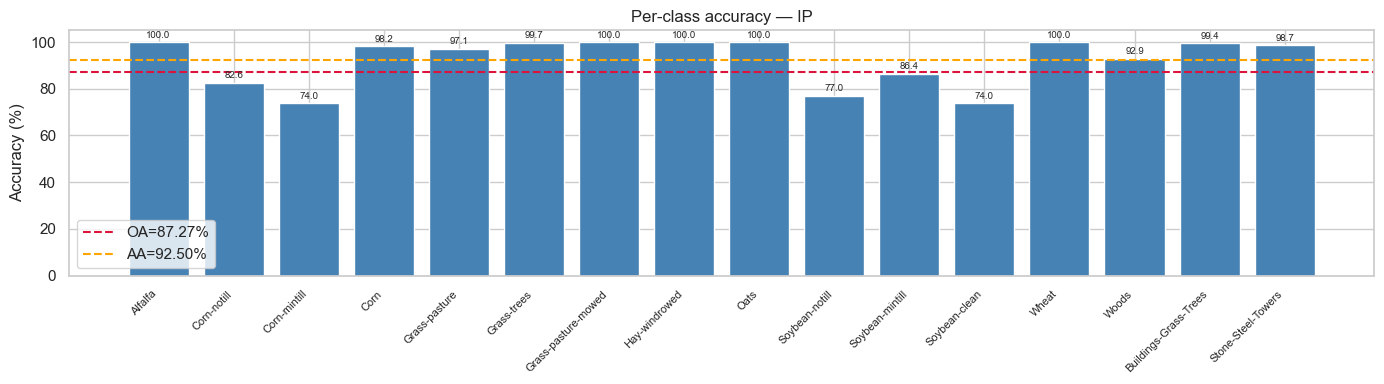

In [7]:
# Per-class accuracy bar
fig, ax = plt.subplots(figsize=(14, 4))
cls_labels = [names.get(i+1, str(i+1)) for i in range(len(per_c))]
bars = ax.bar(cls_labels, [a*100 for a in per_c], color='steelblue', edgecolor='white')
ax.axhline(oa*100, color='crimson', ls='--', lw=1.5, label=f'OA={oa*100:.2f}%')
ax.axhline(aa*100, color='orange',  ls='--', lw=1.5, label=f'AA={aa*100:.2f}%')
ax.set_title(f'Per-class accuracy — {DATASET}')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.set_xticklabels(cls_labels, rotation=45, ha='right', fontsize=8)
for bar, a in zip(bars, per_c):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{a*100:.1f}', ha='center', va='bottom', fontsize=7)
ax.legend()
plt.tight_layout()
plt.show()

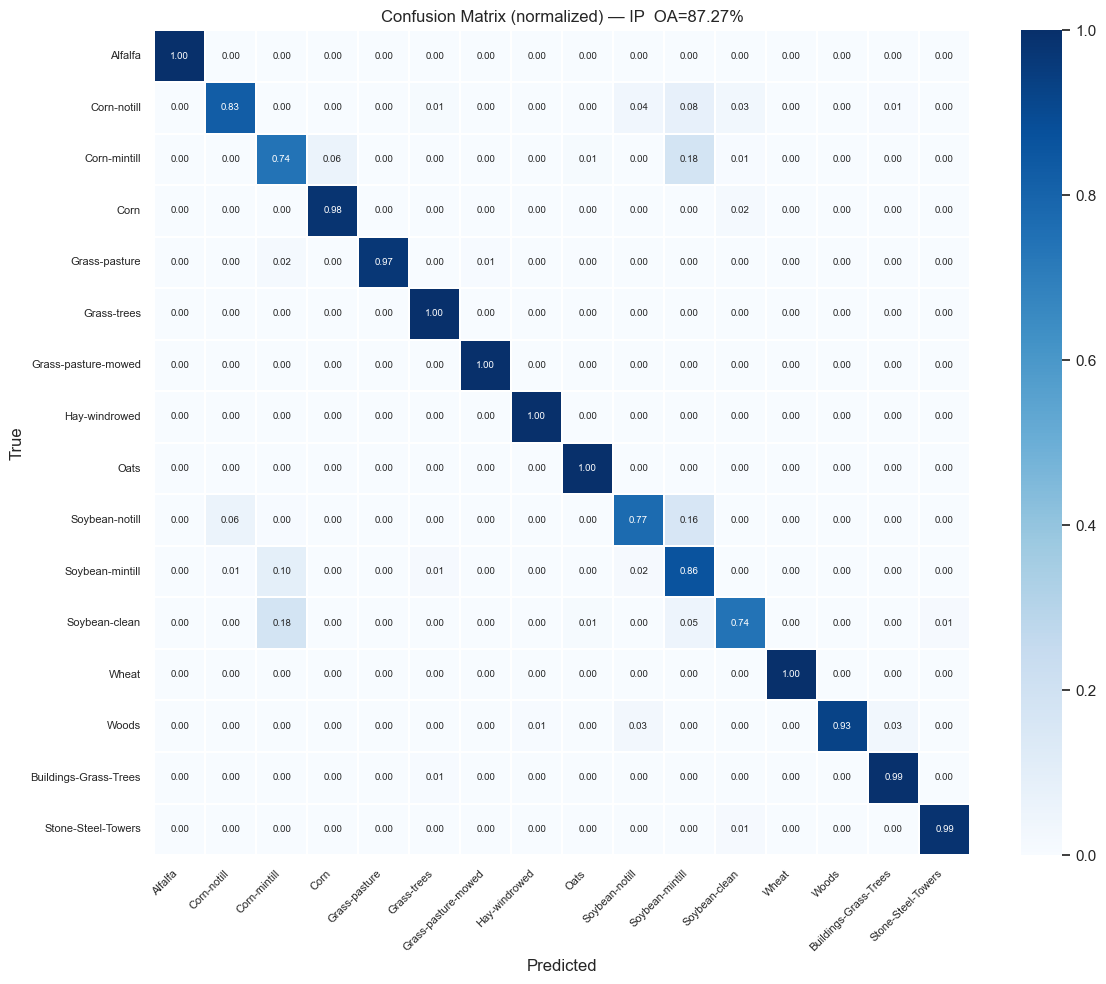

In [8]:
# Confusion matrix
cm = confusion_matrix(trues, preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

tick_labels = [names.get(i+1, str(i+1)) for i in range(cfg.num_classes)]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=tick_labels, yticklabels=tick_labels,
            linewidths=0.3, ax=ax, annot_kws={'size': 7})
ax.set_title(f'Confusion Matrix (normalized) — {DATASET}  OA={oa*100:.2f}%')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

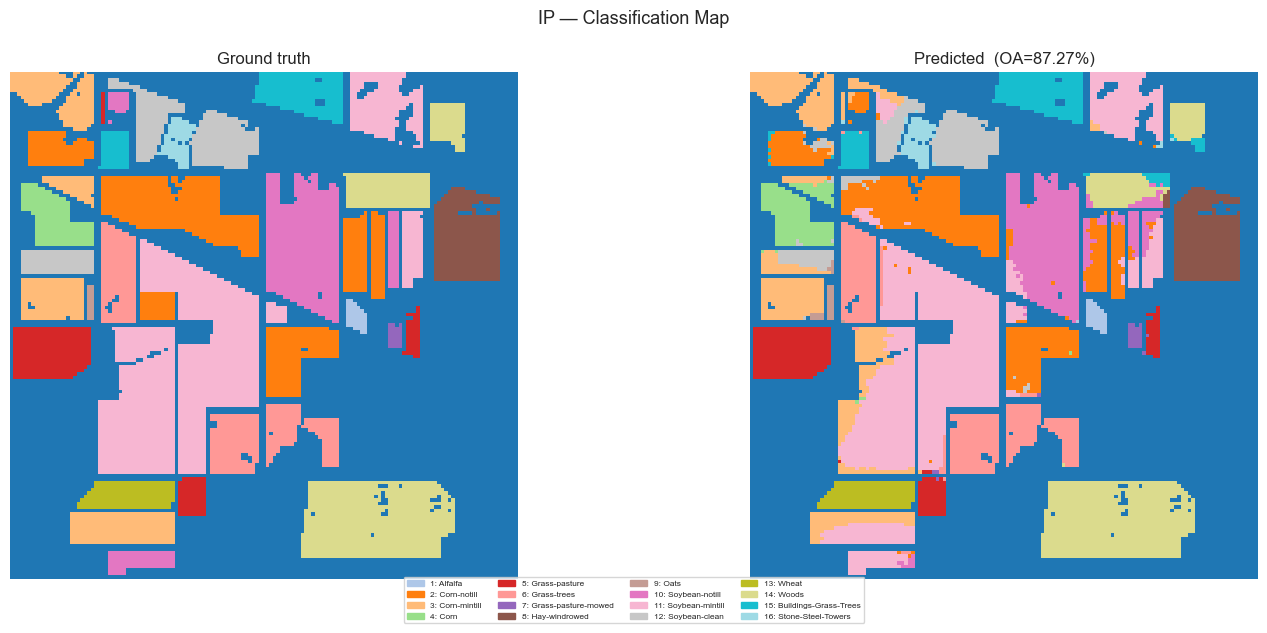

In [9]:
# Карта класифікації на повному зображенні
H, W = labels.shape
pred_map = np.zeros((H, W), dtype=np.int32)  # 0 = фон

# Заповнюємо test пікселі
@torch.no_grad()
def predict_all_labeled(model, hsi_pca, labels, patch_size, batch_size):
    pad = patch_size // 2
    hsi_pad = np.pad(hsi_pca, ((pad,pad),(pad,pad),(0,0)), mode='reflect')
    labeled_pos = np.argwhere(labels > 0)
    all_preds = []
    for start in range(0, len(labeled_pos), batch_size):
        batch_pos = labeled_pos[start:start+batch_size]
        patches = []
        for r,c in batch_pos:
            rp,cp = r+pad, c+pad
            p = hsi_pad[rp-pad:rp+pad+1, cp-pad:cp+pad+1, :]
            patches.append(torch.from_numpy(p.copy()).permute(2,0,1).float())
        x = torch.stack(patches)
        all_preds.extend(model(x).argmax(1).tolist())
    return labeled_pos, np.array(all_preds)

labeled_pos, all_preds = predict_all_labeled(model, hsi_pca, labels, cfg.patch_size, cfg.batch_size)
for (r,c), p in zip(labeled_pos, all_preds):
    pred_map[r, c] = p + 1   # клас 1-based

cmap = plt.cm.get_cmap('tab20', cfg.num_classes + 1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(labels, cmap=cmap, vmin=0, vmax=cfg.num_classes)
axes[0].set_title('Ground truth')
axes[0].axis('off')

axes[1].imshow(pred_map, cmap=cmap, vmin=0, vmax=cfg.num_classes)
axes[1].set_title(f'Predicted  (OA={oa*100:.2f}%)')
axes[1].axis('off')

patches = [mpatches.Patch(color=cmap(c), label=f'{c}: {names.get(c,str(c))}')
           for c in range(1, cfg.num_classes+1)]
fig.legend(handles=patches, fontsize=6, ncol=4,
           loc='lower center', bbox_to_anchor=(0.5, -0.05))
plt.suptitle(f'{DATASET} — Classification Map', fontsize=13)
plt.tight_layout()
plt.show()

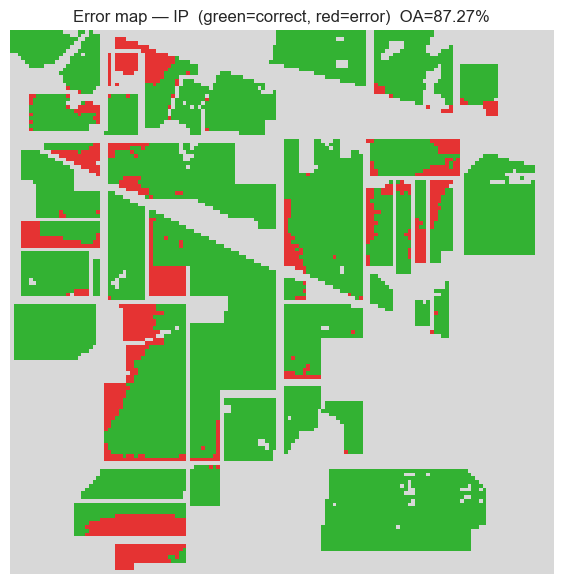

In [10]:
# Карта помилок: зелений=правильно, червоний=неправильно, сірий=фон
error_map = np.zeros((H, W, 3), dtype=np.float32)
error_map[:, :] = [0.85, 0.85, 0.85]   # фон — сірий
for (r,c), p in zip(labeled_pos, all_preds):
    true_cls = int(labels[r,c]) - 1
    if p == true_cls:
        error_map[r, c] = [0.2, 0.7, 0.2]   # правильно — зелений
    else:
        error_map[r, c] = [0.9, 0.2, 0.2]   # неправильно — червоний

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(error_map)
ax.set_title(f'Error map — {DATASET}  (green=correct, red=error)  OA={oa*100:.2f}%')
ax.axis('off')
plt.tight_layout()
plt.show()